In [1]:
# ============================================================
# Notebook 4: Final CatBoost Deployment on Raw Train/Test
# ============================================================

import sys
sys.path.append("../src")

import numpy as np
import pandas as pd

from importlib import reload

import feature_engineering
import preprocessing
import modeling

reload(feature_engineering)
reload(preprocessing)
reload(modeling)

from feature_engineering import clean_and_engineer_base_features
from preprocessing import (
    fit_train_artifacts,
    transform_with_train_artifacts,
    get_final_features
)
from modeling import build_final_catboost, evaluate_binary_model

In [3]:
fraudTest = pd.read_csv('../../../../Data/fraudTest.csv')
fraudTrain = pd.read_csv('../../../../Data/fraudTrain.csv')

print(fraudTrain.shape)
print(fraudTest.shape)

(1296675, 23)
(555719, 23)


In [4]:
train_clean, speed_clip_upper = clean_and_engineer_base_features(fraudTrain)

test_clean, _ = clean_and_engineer_base_features(
    fraudTest,
    speed_clip_upper=speed_clip_upper
)

artifacts = fit_train_artifacts(train_clean)

train_final = transform_with_train_artifacts(train_clean, artifacts)
test_final = transform_with_train_artifacts(test_clean, artifacts)

In [5]:
print("merchant_clean" in train_clean.columns)
print("merchant_type" in train_clean.columns)
print("merchant" in train_clean.columns)

True
True
False


In [6]:
print("high_amt_flag" in train_final.columns)
print("high_amt_flag" in test_final.columns)

True
True


In [7]:
train_final[["amt", "amt_log", "high_amt_flag"]].head()

,amt,amt_log,high_amt_flag
1017,7.27,2.112635,0
2724,52.94,3.987872,0
2726,82.08,4.419804,0
2882,34.79,3.577669,0
2907,27.18,3.338613,0


In [8]:
train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 1017 to 1296427
Data columns (total 46 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   trans_date_trans_time           1296675 non-null  datetime64[ns]
 1   cc_num                          1296675 non-null  int64         
 2   category                        1296675 non-null  object        
 3   amt                             1296675 non-null  float64       
 4   gender                          1296675 non-null  object        
 5   city                            1296675 non-null  object        
 6   state                           1296675 non-null  object        
 7   zip                             1296675 non-null  int64         
 8   job                             1296675 non-null  object        
 9   is_fraud                        1296675 non-null  int64         
 10  txn_distance_km                 1296675 non-

In [9]:
test_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 555719 entries, 157 to 553883
Data columns (total 46 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   trans_date_trans_time           555719 non-null  datetime64[ns]
 1   cc_num                          555719 non-null  int64         
 2   category                        555719 non-null  object        
 3   amt                             555719 non-null  float64       
 4   gender                          555719 non-null  object        
 5   city                            555719 non-null  object        
 6   state                           555719 non-null  object        
 7   zip                             555719 non-null  int64         
 8   job                             555719 non-null  object        
 9   is_fraud                        555719 non-null  int64         
 10  txn_distance_km                 555719 non-null  float64   

In [10]:
artifacts = fit_train_artifacts(train_clean)

train_final = transform_with_train_artifacts(train_clean, artifacts)
test_final = transform_with_train_artifacts(test_clean, artifacts)

final_features = get_final_features(
    category_cols=artifacts["category_cols"],
    impute_cols=artifacts["impute_cols"]
)

In [11]:
print("high_amt_flag" in train_final.columns)
print("high_amt_flag" in test_final.columns)
print("high_amt_flag" in final_features)

True
True
True


In [12]:
# ============================================================
# 1. Prepare final train/test matrices
# ============================================================

target_col = "is_fraud"

X_train = train_final[final_features].copy()
y_train = train_final[target_col].copy()

X_test = test_final[final_features].copy()
y_test = test_final[target_col].copy()

# Safety check: make sure test columns exactly match train columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

X_train: (1296675, 33)
X_test: (555719, 33)
Train fraud rate: 0.005788651743883394
Test fraud rate: 0.0038598644278853163


In [13]:
# ============================================================
# 2. Train final CatBoost model on full train
# ============================================================

cat_final = build_final_catboost()

cat_final.fit(X_train, y_train)

In [14]:
# ============================================================
# 3. Predict and evaluate on test
# ============================================================

y_prob_test, metrics = evaluate_binary_model(
    cat_final,
    X_test,
    y_test
)

print(f"Test ROC-AUC: {metrics['roc_auc']:.4f}")
print(f"Test PR-AUC: {metrics['pr_auc']:.4f}")

Test ROC-AUC: 0.9940
Test PR-AUC: 0.8762


In [15]:
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score, f1_score, recall_score

threshold = 0.5
y_pred_test = (y_prob_test >= threshold).astype(int)

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_test))
print("----------------")

print("\nClassification Report")
print(classification_report(y_test, y_pred_test))
print("----------------\n")

print(f"Test F1 Score : {f1_score(y_test, y_pred_test):.4f}")
print("\n----------------")
print(f"Test Recall Score: {recall_score(y_test, y_pred_test):.4f}")

Confusion Matrix
[[553428    146]
 [   543   1602]]
----------------

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.92      0.75      0.82      2145

    accuracy                           1.00    555719
   macro avg       0.96      0.87      0.91    555719
weighted avg       1.00      1.00      1.00    555719

----------------

Test F1 Score : 0.8230

----------------
Test Recall Score: 0.7469


# Model Evaluation Interpretation

## Overall Test Performance

The final CatBoost model achieved:

- Test ROC-AUC: 0.9940
- Test PR-AUC: 0.8762
- Test F1 Score: 0.8230
- Test Recall: 0.7469

The extremely high ROC-AUC indicates that the model separates fraud and non-fraud transactions very effectively overall.

Because fraud detection is a highly imbalanced classification problem, PR-AUC is more informative than ROC-AUC. The strong PR-AUC score suggests that the model ranks fraudulent transactions near the top very effectively.

---

# Why Accuracy Is Not the Main Metric

Fraud detection datasets are highly imbalanced.

In this dataset:

- Most transactions are non-fraud
- Only a very small percentage are fraud

Because of this imbalance, a model could achieve very high accuracy simply by predicting everything as non-fraud.

Therefore, metrics such as:

- PR-AUC
- Precision
- Recall
- F1 Score
- Precision@K
- Recall@K

are much more meaningful than overall accuracy.

---

In [16]:
eval_df = test_final.copy()
eval_df["fraud_probability"] = y_prob_test
eval_df["is_fraud"] = y_test.values

eval_df = eval_df.sort_values("fraud_probability", ascending=False)

for k in [100, 500, 1000, 5000]:
    top_k = eval_df.head(k)
    precision_at_k = top_k["is_fraud"].mean()
    recall_at_k = top_k["is_fraud"].sum() / eval_df["is_fraud"].sum()
    
    print(f"Top {k}: Precision@K={precision_at_k:.4f}, Recall@K={recall_at_k:.4f}")

Top 100: Precision@K=1.0000, Recall@K=0.0466
Top 500: Precision@K=1.0000, Recall@K=0.2331
Top 1000: Precision@K=1.0000, Recall@K=0.4662
Top 5000: Precision@K=0.3914, Recall@K=0.9124


# Precision and Recall

## Recall

Recall measures:

> Among all real fraud transactions, how many fraud cases were successfully detected by the model.

Formula: Recall = TP / (TP + FN)


Where:

- TP = True Positives
- FN = False Negatives

High Recall means the model misses fewer fraud cases.

---

## Precision

Precision measures:

> Among all transactions flagged as fraud by the model, how many were actually fraud.

Formula: F1 = 2 × (Precision × Recall) / (Precision + Recall)


Unlike a regular average, the harmonic mean penalizes situations where one metric is high but the other is low.

Therefore:

- High Precision + Low Recall → lower F1
- Low Precision + High Recall → lower F1
- Both high → strong F1

The model achieved:

- F1 Score = 0.823

This indicates that the model maintains a strong balance between fraud detection capability (Recall) and fraud alert quality (Precision).

---

# Confusion Matrix Interpretation

Confusion Matrix:

[[553428 146]
[ 543 1602]]


This means:

- 553,428 legitimate transactions were correctly classified
- 1,602 fraud transactions were correctly detected
- 543 fraud transactions were missed
- 146 legitimate transactions were incorrectly flagged as fraud

The relatively small number of false positives indicates strong fraud alert precision.

The model also successfully captures most fraud transactions while keeping investigation noise low.

---

# Top-K Evaluation

In real-world fraud systems, investigators often cannot manually review every transaction.

Instead, transactions are ranked by fraud risk score, and only the highest-risk transactions are investigated.

Therefore, Precision@K and Recall@K are extremely important operational metrics.

---

# Recall@K

Recall@K measures:

> Among all real fraud transactions, how many are captured within the top K highest-risk transactions.

---

# Precision@K

Precision@K measures:

> Among the top K highest-risk transactions, how many are actually fraud.

---

# Top-K Results

| K | Precision@K | Recall@K |
|---|---|---|
| 100 | 1.0000 | 0.0466 |
| 500 | 1.0000 | 0.2331 |
| 1000 | 1.0000 | 0.4662 |
| 5000 | 0.3914 | 0.9124 |

---

# Interpretation of Top-K Results

## Top 500

Precision@500 = 1.0000

This means:

> The top 500 highest-risk transactions identified by the model were all truly fraudulent transactions.

Recall@500 = 0.2331

This means:

> The top 500 highest-risk transactions already captured 23.31% of all fraud cases.

This indicates extremely strong fraud ranking performance.

---

# Top 5000

Precision@5000 = 0.3914

This means:

> Among the top 5000 highest-risk transactions, 39.14% were truly fraud.

Recall@5000 = 0.9124

This means:

> 91.24% of all fraud transactions were already contained within the top 5000 highest-risk transactions.

This demonstrates that the model concentrates the vast majority of fraud risk into a relatively small subset of transactions.

---

# Business Interpretation

The model creates a strong trade-off between:

- Precision (avoiding unnecessary investigations)
- Recall (capturing as much fraud as possible)

Smaller K values:

- Higher Precision
- Lower Recall
- More conservative investigation strategy

Larger K values:

- Lower Precision
- Higher Recall
- More aggressive fraud detection strategy

The optimal threshold depends on business goals, investigation capacity, operational cost, and fraud loss tolerance.

---

# Final Conclusion

The CatBoost model demonstrates extremely strong fraud ranking performance.

Key strengths include:

- Strong PR-AUC on highly imbalanced fraud data
- Excellent fraud prioritization capability
- Very high Precision@K at operationally meaningful thresholds
- Strong Recall while maintaining relatively few false positives

These results suggest that the feature engineering pipeline and CatBoost modeling approach are highly effective for structured tabular fraud detection problems.

In [20]:
# ============================================================
# 4. Save test predictions
# ============================================================

test_predictions = test_final.copy()
test_predictions["fraud_probability"] = y_prob_test

cols_to_export = [
    "trans_date_trans_time",
    "cc_num",
    "category",
    "amt",
    "is_fraud",
    "fraud_probability"
]

test_predictions[cols_to_export].head()

# test_predictions[cols_to_export].to_csv(
#     "../../../../Data/catboost_test_predictions.csv",
#     index=False
# )

,trans_date_trans_time,cc_num,category,amt,is_fraud,fraud_probability
157,2020-06-21 13:05:42,60416207185,home,124.66,0,0.000016
741,2020-06-21 16:25:36,60416207185,misc_pos,78.52,0,0.000325
3047,2020-06-22 07:58:33,60416207185,gas_transport,65.25,0,0.000006
4351,2020-06-22 15:32:31,60416207185,kids_pets,87.74,0,0.000368
7695,2020-06-23 12:28:54,60416207185,personal_care,148.02,0,0.000648


### SHAP _vs_ CatBoost's Feature Selection

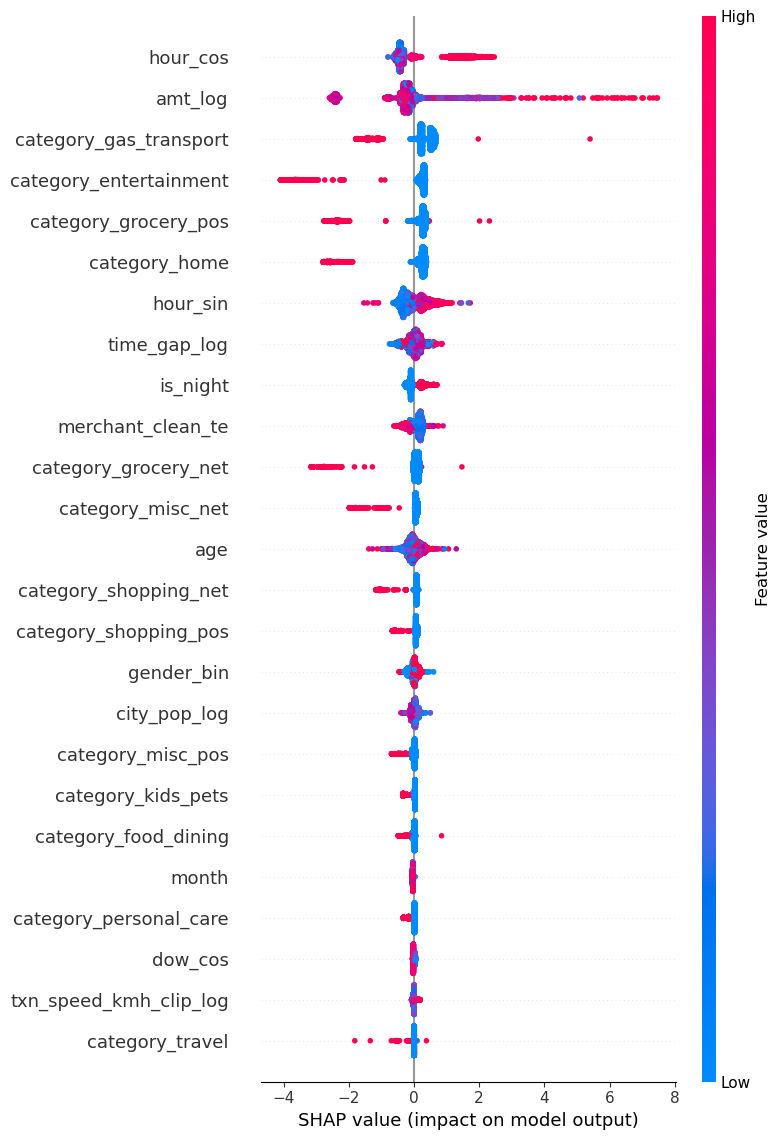

In [26]:
import os
import shap
import matplotlib.pyplot as plt

# Create outputs folder
os.makedirs("../images", exist_ok=True)

# ============================================================
# Create SHAP explainer
# ============================================================

explainer = shap.TreeExplainer(cat_final)

# ============================================================
# Sample test data
# ============================================================

X_shap = X_test.sample(
    n=5000,
    random_state=42
)

# ============================================================
# Compute SHAP values
# ============================================================

shap_values = explainer.shap_values(X_shap)

# ============================================================
# SHAP Summary Plot
# ============================================================

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=25,
    show=False
)

# shap.summary_plot(
#     shap_values,
#     X_shap,
#     plot_type="bar",
#     max_display=25,
#     cmap='viridis'
# )

# Save figure
plt.savefig(
    "../images/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Convert SHAP values into feature importance table
# ============================================================

shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

shap_importance.head(15)

,feature,mean_abs_shap
0,hour_cos,0.627077
1,amt_log,0.611321
2,category_gas_transport,0.500715
3,category_entertainment,0.494830
4,category_grocery_pos,0.465967
5,category_home,0.450584
6,hour_sin,0.295570
7,time_gap_log,0.179815
8,is_night,0.174319
9,merchant_clean_te,0.171380


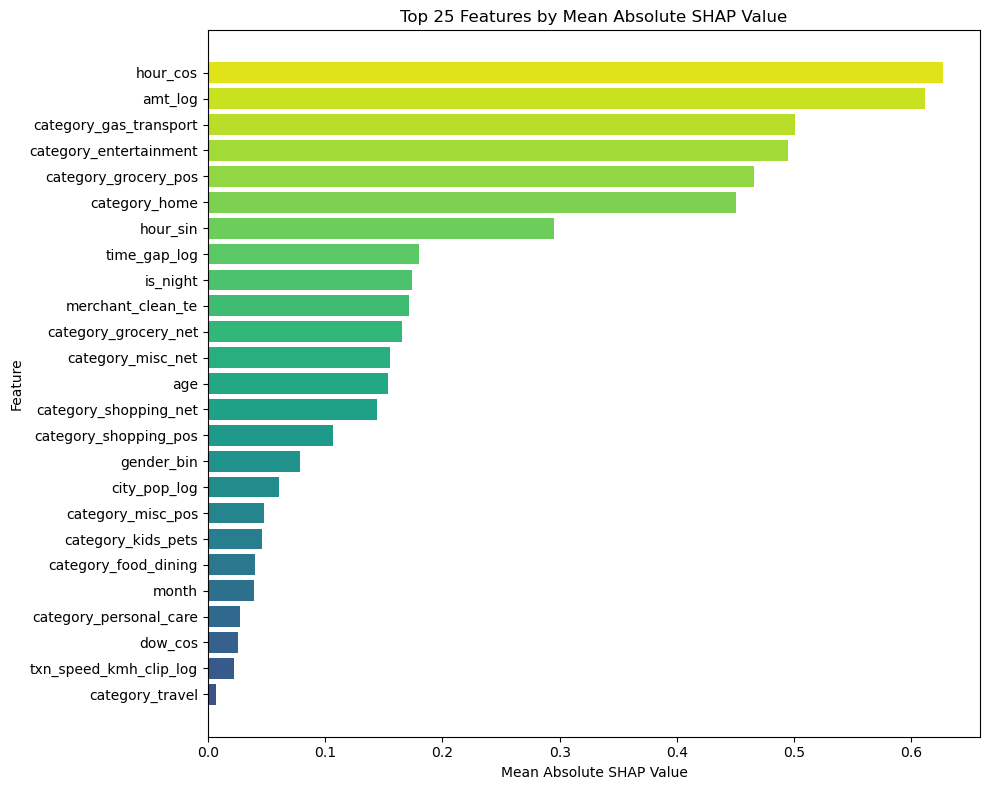

In [28]:
# ============================================================
# 2. Custom gradient SHAP bar plot
# ============================================================

top_n = 25

plot_df = (
    shap_importance
    .head(top_n)
    .sort_values("mean_abs_shap")
)

colors = plt.cm.viridis(
    np.linspace(0.25, 0.95, len(plot_df))
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["feature"],
    plot_df["mean_abs_shap"],
    color=colors
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 25 Features by Mean Absolute SHAP Value")

plt.tight_layout()

# SAVE FIRST
# plt.savefig(
#     "outputs/shap_gradient_barplot.png",
#     dpi=300,
#     bbox_inches='tight',
#     transparent=True
# )
plt.savefig(
    "../images/shap_gradient_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

# SHOW AFTER SAVE
plt.show()

plt.close()

# Fraud Risk Drivers

## The model suggests that fraud risk is primarily driven by:

- transaction timing
- transaction amount
- merchant category
- merchant historical fraud risk
- behavioral transaction patterns

## High-risk behaviors include:

- nighttime transactions
- high transaction amounts
- risky merchant categories
- short time-gap spending behavior
- abnormal transaction velocity patterns

The model relies more heavily on behavioral and transactional signals than demographic variables, which suggests the model is learning fraud behavior patterns rather than simple customer demographic characteristics.

The model successfully concentrated most fraud cases within the highest-risk ranked transactions, which is highly valuable for investigation prioritization in real-world fraud operations. CatBoost achieved the strongest overall performance with excellent PR-AUC and strong ranking behavior under severe class imbalance.

